# ViT-B/16 Training - Skin Tone 2
This notebook contains a complete end-to-end training and evaluation pipeline for the Skin-Tone-2 dataset.

Run cells in order. Training starts only when you run the training cell.

In [1]:
# Install dependencies (run once per fresh environment)
%pip install -q torch torchvision numpy pillow pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports
import os
import csv
import copy
import time
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import vit_b_16, ViT_B_16_Weights

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
 )

In [3]:
# Reproducibility + device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Training config
BATCH_SIZE = 8 if torch.cuda.is_available() else 16
NUM_WORKERS = 2
NUM_EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15  # test ratio is remaining 0.15

# Stability + resume config
USE_AMP = torch.cuda.is_available()
GRAD_ACCUM_STEPS = 2  # effective batch ~= BATCH_SIZE * GRAD_ACCUM_STEPS
MAX_GRAD_NORM = 1.0
SAVE_EVERY_EPOCH = 1
RESUME_IF_AVAILABLE = True

Device: cuda


In [4]:
# Dataset discovery + transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class TransformedSubset(Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]


def _find_split_dirs(root: Path):
    split_map = {"train": None, "val": None, "test": None}
    aliases = {
        "train": {"train", "training"},
        "val": {"val", "valid", "validation"},
        "test": {"test"},
    }
    for dirpath, _, _ in os.walk(root):
        folder_name = Path(dirpath).name.lower()
        for key, names in aliases.items():
            if folder_name in names and split_map[key] is None:
                split_map[key] = Path(dirpath)
    return split_map


def _try_make_imagefolder(path: Path, transform=None):
    try:
        ds = ImageFolder(str(path), transform=transform)
        if len(ds.classes) > 0 and len(ds) > 0:
            return ds
    except Exception:
        pass
    return None


def _find_imagefolder_root(root: Path, max_depth: int = 6):
    candidates = [root]
    for p in root.rglob("*"):
        if p.is_dir() and len(p.relative_to(root).parts) <= max_depth:
            candidates.append(p)

    seen = set()
    best_path = None
    best_count = -1

    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)

        ds = _try_make_imagefolder(candidate)
        if ds is not None and len(ds) > best_count:
            best_path = candidate
            best_count = len(ds)

    return best_path


def _extract_valid_zip_and_find_root(root: Path):
    import zipfile

    zip_files = sorted(root.glob("*.zip"))
    if not zip_files:
        return None

    out_base = root / "_auto_extracted"
    out_base.mkdir(parents=True, exist_ok=True)

    for zf in zip_files:
        target = out_base / zf.stem
        if not target.exists():
            target.mkdir(parents=True, exist_ok=True)
            try:
                with zipfile.ZipFile(zf, "r") as z:
                    z.extractall(target)
                print(f"Extracted: {zf} -> {target}")
            except Exception as exc:
                print(f"Skip invalid zip {zf}: {exc}")
                continue

        found = _find_imagefolder_root(target, max_depth=7)
        if found is not None:
            return found
    return None


def _candidate_roots():
    env_root = os.getenv("DATASET_ROOT")
    cwd = Path.cwd()
    project_root = cwd.parents[1] if len(cwd.parents) >= 2 else cwd

    roots = [
        Path(env_root) if env_root else None,
        project_root / "dataset" / "Skin-Tone-2",
        project_root / "dataset" / "_extracted" / "kaggle-skin-tone",
        project_root / "dataset" / "_extracted" / "skin-tone",
        project_root / "dataset",
    ]
    return [r for r in roots if r is not None and r.exists()]


def resolve_data_root() -> Path:
    # 1) First pass: try known locations.
    checked = []
    for root in _candidate_roots():
        checked.append(str(root))
        found = _find_imagefolder_root(root, max_depth=7)
        if found is not None:
            print("Resolved dataset root:", found)
            return found

    # 2) Second pass: try extracting zip files in known locations.
    for root in _candidate_roots():
        extracted = _extract_valid_zip_and_find_root(root)
        if extracted is not None:
            print("Resolved dataset root from extracted zip:", extracted)
            return extracted

    # 3) Fail with useful diagnostics.
    raise RuntimeError(
        "No valid image dataset found. Checked roots: " + ", ".join(checked) +
        ". Set DATASET_ROOT to the folder that directly contains class subfolders with images."
    )


def build_datasets(data_root: Path):
    split_dirs = _find_split_dirs(data_root)

    # Case A: split folders exist under root.
    if all(split_dirs.values()):
        train_root = _find_imagefolder_root(split_dirs["train"], max_depth=6)
        val_root = _find_imagefolder_root(split_dirs["val"], max_depth=6)
        test_root = _find_imagefolder_root(split_dirs["test"], max_depth=6)

        if all([train_root, val_root, test_root]):
            print("Using split roots:")
            print(" train ->", train_root)
            print(" val   ->", val_root)
            print(" test  ->", test_root)
            train_set = ImageFolder(str(train_root), transform=train_transform)
            val_set = ImageFolder(str(val_root), transform=eval_transform)
            test_set = ImageFolder(str(test_root), transform=eval_transform)
            class_names = train_set.classes
            return train_set, val_set, test_set, class_names

    # Case B: one class-folder dataset root, then split by random indices.
    direct_root = _find_imagefolder_root(data_root, max_depth=1) or data_root
    probe_ds = ImageFolder(str(direct_root))
    num_items = len(probe_ds)

    indices = np.arange(num_items)
    np.random.shuffle(indices)

    train_end = int(num_items * TRAIN_RATIO)
    val_end = train_end + int(num_items * VAL_RATIO)

    train_idx = indices[:train_end].tolist()
    val_idx = indices[train_end:val_end].tolist()
    test_idx = indices[val_end:].tolist()

    train_base = ImageFolder(str(direct_root), transform=train_transform)
    eval_base = ImageFolder(str(direct_root), transform=eval_transform)

    train_set = TransformedSubset(train_base, train_idx)
    val_set = TransformedSubset(eval_base, val_idx)
    test_set = TransformedSubset(eval_base, test_idx)
    class_names = probe_ds.classes
    return train_set, val_set, test_set, class_names

In [5]:
# Build datasets and dataloaders
data_root = resolve_data_root()
train_set, val_set, test_set, class_names = build_datasets(data_root)
num_classes = len(class_names)

print("Dataset root:", data_root)
print("Classes:", class_names)
print("Train/Val/Test sizes:", len(train_set), len(val_set), len(test_set))

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

Resolved dataset root: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Tone-2
Using split roots:
 train -> /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Tone-2/train
 val   -> /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Tone-2/valid
 test  -> /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Tone-2/test
Dataset root: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Tone-2
Classes: ['dark', 'light', 'mid-dark', 'mid-light']
Train/Val/Test sizes: 25079 5373 5377


In [6]:
# Build ViT-B/16 model (transfer learning)
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head for Skin-Tone-2 classes
in_features = model.heads.head.in_features
model.heads = nn.Sequential(
    nn.LayerNorm(in_features),
    nn.Linear(in_features, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes),
)

# Unfreeze new head and last encoder blocks for better adaptation
for param in model.heads.parameters():
    param.requires_grad = True
for param in model.encoder.layers[-2:].parameters():
    param.requires_grad = True

model = model.to(device)

In [7]:
# Quick sanity checks
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")
print("Classifier head:", model.heads)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Trainable params: 14,573,060 / 86,195,972
Classifier head: Sequential(
  (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (1): Linear(in_features=768, out_features=512, bias=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=4, bias=True)
)
Class names: ['dark', 'light', 'mid-dark', 'mid-light']
Number of classes: 4


In [8]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    scaler=None,
    grad_accum_steps=1,
    max_grad_norm=1.0,
    use_amp=False,
):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    grad_accum_steps = max(int(grad_accum_steps), 1)
    optimizer.zero_grad(set_to_none=True)

    for step, (inputs, labels) in enumerate(loader, start=1):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss = loss / grad_accum_steps

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        should_step = (step % grad_accum_steps == 0) or (step == len(loader))
        if should_step:
            if scaler is not None and use_amp:
                scaler.unscale_(optimizer)

            if max_grad_norm is not None and max_grad_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            if scaler is not None and use_amp:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            optimizer.zero_grad(set_to_none=True)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size * grad_accum_steps
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    avg_loss = running_loss / max(total, 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(inputs)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = running_loss / max(total, 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc, np.array(all_preds), np.array(all_labels)

In [9]:
def _write_history_csv(history, history_csv_path):
    history_csv_path = Path(history_csv_path)
    history_csv_path.parent.mkdir(parents=True, exist_ok=True)

    with history_csv_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=[
                "epoch",
                "train_loss",
                "train_acc",
                "train_precision",
                "train_recall",
                "train_f1",
                "val_loss",
                "val_acc",
                "val_precision",
                "val_recall",
                "val_f1",
            ],
        )
        writer.writeheader()
        writer.writerows(history)


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=NUM_EPOCHS,
    save_path="best_vit_skin_tone.pth",
    history_csv_path="vit_skin_tone_metrics.csv",
    resume_state_path=None,
    resume_if_available=RESUME_IF_AVAILABLE,
    save_every_epoch=SAVE_EVERY_EPOCH,
    use_amp=USE_AMP,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    max_grad_norm=MAX_GRAD_NORM,
):
    start_time = time.time()
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    history = []
    best_epoch = 0

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    history_csv_path = Path(history_csv_path)
    history_csv_path.parent.mkdir(parents=True, exist_ok=True)

    if resume_state_path is None:
        resume_state_path = save_path.with_name(f"{save_path.stem}_resume.pt")
    resume_state_path = Path(resume_state_path)
    resume_state_path.parent.mkdir(parents=True, exist_ok=True)

    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    start_epoch = 1

    if resume_if_available and resume_state_path.exists():
        resume_state = torch.load(resume_state_path, map_location=device)
        model.load_state_dict(resume_state["model_state"])
        optimizer.load_state_dict(resume_state["optimizer_state"])

        if scheduler is not None and resume_state.get("scheduler_state") is not None:
            scheduler.load_state_dict(resume_state["scheduler_state"])

        if resume_state.get("scaler_state") is not None:
            scaler.load_state_dict(resume_state["scaler_state"])

        best_val_acc = float(resume_state.get("best_val_acc", 0.0))
        best_epoch = int(resume_state.get("best_epoch", 0))
        history = resume_state.get("history", [])

        if resume_state.get("best_model_state") is not None:
            best_weights = resume_state["best_model_state"]

        start_epoch = int(resume_state.get("epoch", 0)) + 1
        print(f"Resumed from {resume_state_path} at epoch {start_epoch - 1}")

    for epoch in range(start_epoch, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            scaler=scaler,
            grad_accum_steps=grad_accum_steps,
            max_grad_norm=max_grad_norm,
            use_amp=use_amp,
        )

        _, _, train_pred, train_true = evaluate(model, train_loader, criterion, device)
        val_loss, val_acc, val_pred, val_true = evaluate(model, val_loader, criterion, device)

        train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
            train_true,
            train_pred,
            average="weighted",
            zero_division=0,
        )
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            val_true,
            val_pred,
            average="weighted",
            zero_division=0,
        )

        if scheduler is not None:
            scheduler.step(val_acc)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_precision": float(train_precision),
            "train_recall": float(train_recall),
            "train_f1": float(train_f1),
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_precision": float(val_precision),
            "val_recall": float(val_recall),
            "val_f1": float(val_f1),
        })

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Train P/R/F1: {train_precision:.4f}/{train_recall:.4f}/{train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
            f"Val P/R/F1: {val_precision:.4f}/{val_recall:.4f}/{val_f1:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())

        _write_history_csv(history, history_csv_path)

        if (epoch % max(int(save_every_epoch), 1) == 0) or (epoch == epochs):
            resume_payload = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
                "scaler_state": scaler.state_dict() if use_amp else None,
                "best_val_acc": float(best_val_acc),
                "best_epoch": int(best_epoch),
                "best_model_state": best_weights,
                "history": history,
                "config": {
                    "epochs": epochs,
                    "use_amp": use_amp,
                    "grad_accum_steps": grad_accum_steps,
                    "max_grad_norm": max_grad_norm,
                },
            }
            torch.save(resume_payload, resume_state_path)
            print(f"Saved resume state: {resume_state_path}")

    elapsed = time.time() - start_time
    print(f"Training complete in {elapsed/60:.1f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")

    model.load_state_dict(best_weights)
    if best_epoch == 0:
        best_epoch = epochs
    best_model_path = save_path.with_name(f"{save_path.stem}_best_epoch_{best_epoch}{save_path.suffix}")
    torch.save(best_weights, best_model_path)
    print(f"Best weights saved to: {best_model_path}")

    best_history_csv_path = history_csv_path.with_name(
        f"{history_csv_path.stem}_best_epoch_{best_epoch}{history_csv_path.suffix}"
    )
    _write_history_csv(history, best_history_csv_path)
    print(f"Training/validation metrics saved to: {best_history_csv_path}")

    return model, history, best_val_acc, best_epoch, str(best_model_path), str(best_history_csv_path)

In [10]:
@torch.no_grad()
def evaluate_test(model, test_loader, criterion, device):
    test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    return test_loss, test_acc, y_pred, y_true

CHECKPOINT_PATH = Path.cwd() / "best_vit_skin_tone.pth"
HISTORY_CSV_PATH = Path.cwd() / "vit_skin_tone_metrics.csv"
RESUME_STATE_PATH = Path.cwd() / "vit_skin_tone_resume.pt"
print("Checkpoint will be saved at:", CHECKPOINT_PATH)
print("Training/validation CSV will be saved at:", HISTORY_CSV_PATH)
print("Resume state will be saved at:", RESUME_STATE_PATH)

Checkpoint will be saved at: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/best_vit_skin_tone.pth
Training/validation CSV will be saved at: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/vit_skin_tone_metrics.csv
Resume state will be saved at: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/vit_skin_tone_resume.pt


In [11]:
# Training starts when this cell is run
model, history, best_val_acc, best_epoch, best_model_path, saved_history_csv_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=NUM_EPOCHS,
    save_path=str(CHECKPOINT_PATH),
    history_csv_path=str(HISTORY_CSV_PATH),
    resume_state_path=str(RESUME_STATE_PATH),
    resume_if_available=RESUME_IF_AVAILABLE,
    save_every_epoch=SAVE_EVERY_EPOCH,
    use_amp=USE_AMP,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    max_grad_norm=MAX_GRAD_NORM,
)

test_loss, test_acc, y_pred, y_true = evaluate_test(model, test_loader, criterion, device)

Epoch 001/40 | Train Loss: 0.8228 | Train Acc: 72.85% | Train P/R/F1: 0.7454/0.7554/0.7378 | Val Loss: 0.7314 | Val Acc: 78.11% | Val P/R/F1: 0.7737/0.7811/0.7671
Saved resume state: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/vit_skin_tone_resume.pt
Epoch 002/40 | Train Loss: 0.7341 | Train Acc: 78.22% | Train P/R/F1: 0.8029/0.8010/0.8011 | Val Loss: 0.6513 | Val Acc: 83.79% | Val P/R/F1: 0.8407/0.8379/0.8386
Saved resume state: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/vit_skin_tone_resume.pt
Epoch 003/40 | Train Loss: 0.6992 | Train Acc: 80.45% | Train P/R/F1: 0.8193/0.8251/0.8197 | Val Loss: 0.6140 | Val Acc: 85.35% | Val P/R/F1: 0.8482/0.8535/0.8489
Saved resume state: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/vit_skin_tone_resume.pt
Epoch 004/40 | Train Loss: 0.6686 | Train Acc: 81.80% | Train P/R/F1: 0.8252/0.8317/0.8222 | Val Loss: 0.6086 | Val Acc: 84.98% | Val P/R/F1: 0.8425/0.8498/0.8444
Saved resume state: /media/aejaz/

In [12]:
# Detailed evaluation artifacts with train/val/test split metrics
EVAL_PREFIX = "vit_skin_tone"
EVAL_DIR = Path.cwd() / f"{EVAL_PREFIX}_evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

if "history" not in locals() or len(history) == 0:
    raise RuntimeError("Train the model first so history and best_epoch are available.")

if "best_model_path" in locals() and Path(best_model_path).exists():
    model.load_state_dict(torch.load(Path(best_model_path), map_location=device))

@torch.no_grad()
def evaluate_split(split_name, loader):
    split_loss, split_acc, y_pred, y_true = evaluate(model, loader, criterion, device)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return {
        "split": split_name,
        "loss": float(split_loss),
        "accuracy": float(split_acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "y_true": y_true,
        "y_pred": y_pred,
    }

split_metrics = {
    "train": evaluate_split("train", train_loader),
    "val": evaluate_split("val", val_loader),
    "test": evaluate_split("test", test_loader),
}

print("\nSplit-wise metrics")
print("=" * 80)
print(f"{'Split':<8} {'Acc':<10} {'Prec':<10} {'Recall':<10} {'F1':<10}")
print("-" * 80)
for split_name in ["train", "val", "test"]:
    m = split_metrics[split_name]
    print(f"{split_name:<8} {m['accuracy']:<10.4f} {m['precision']:<10.4f} {m['recall']:<10.4f} {m['f1_score']:<10.4f}")
print("=" * 80)

test_metrics = split_metrics["test"]
summary = {
    "class_names": class_names,
    "best_val_acc": float(best_val_acc),
    "split_metrics": {
        k: {
            "loss": v["loss"],
            "accuracy": v["accuracy"],
            "precision": v["precision"],
            "recall": v["recall"],
            "f1_score": v["f1_score"],
        }
        for k, v in split_metrics.items()
    },
}

with open(EVAL_DIR / f"final_metrics_best_epoch_{best_epoch}.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

report = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
with open(EVAL_DIR / f"classification_report_best_epoch_{best_epoch}.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

pd.DataFrame(
    [
        {
            "split": k,
            "loss": v["loss"],
            "accuracy": v["accuracy"],
            "precision": v["precision"],
            "recall": v["recall"],
            "f1_score": v["f1_score"],
        }
        for k, v in split_metrics.items()
    ]
).to_csv(EVAL_DIR / f"split_metrics_best_epoch_{best_epoch}.csv", index=False)

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(EVAL_DIR / f"confusion_matrix_best_epoch_{best_epoch}.csv")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(EVAL_DIR / "confusion_matrix.png", dpi=200)
plt.close()

hist_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "loss_curve.png", dpi=200)
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(hist_df["epoch"], hist_df["train_acc"], label="Train Acc")
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "accuracy_curve.png", dpi=200)
plt.close()

print("Saved detailed evaluation to:", EVAL_DIR)

/tmp/ipykernel_16116/2031438459.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(Path(best_model_path), map_location=device))



Split-wise metrics
Split    Acc        Prec       Recall     F1        
--------------------------------------------------------------------------------
train    92.8665    0.9282     0.9287     0.9284    
val      91.7365    0.9164     0.9174     0.9167    
test     92.0216    0.9192     0.9202     0.9194    
Saved detailed evaluation to: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/vit_skin_tone_evaluation


In [13]:
# Optional final checkpoint save
torch.save(model.state_dict(), "vit_skin_tone_last.pth")
print("Saved last checkpoint: vit_skin_tone_last.pth")

Saved last checkpoint: vit_skin_tone_last.pth


Working directory: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2
Project root: /media/aejaz/New Volume/Projects/DERMAVISION
Dataset root: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Tone-2
Test dir: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Tone-2/test
Using folder label format: test/<class_name>/*
Device: cuda


/tmp/ipykernel_492510/2063119774.py:216: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


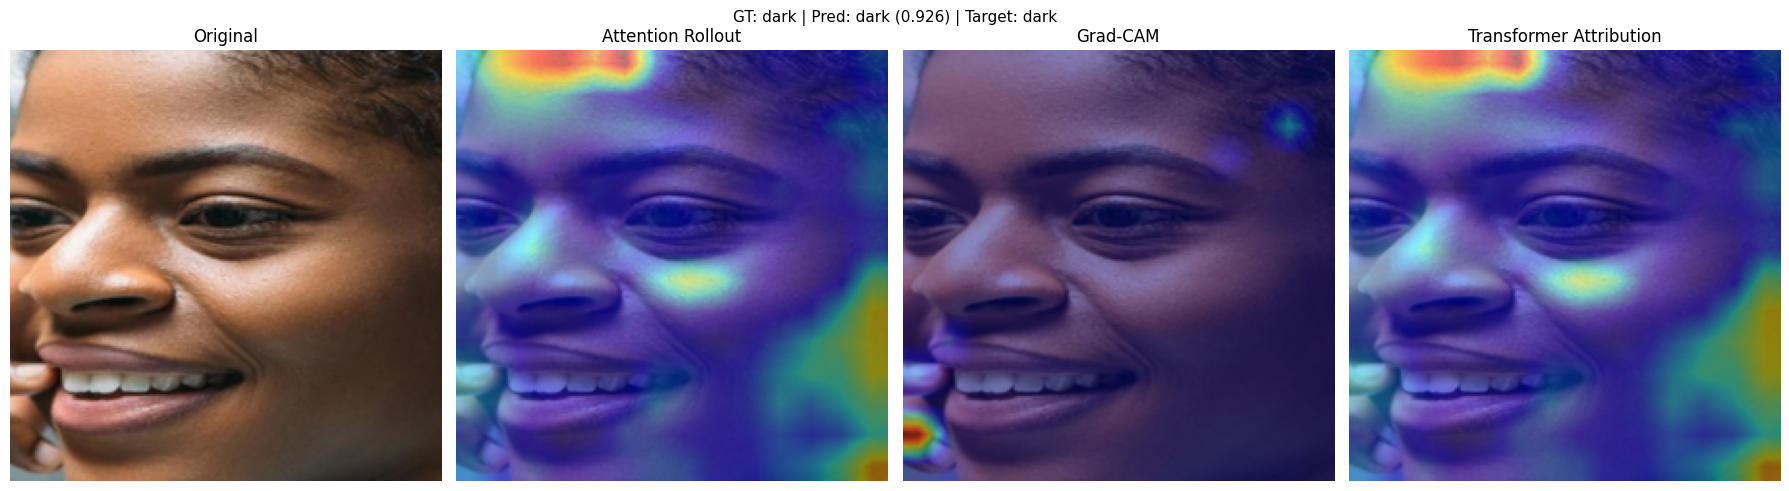

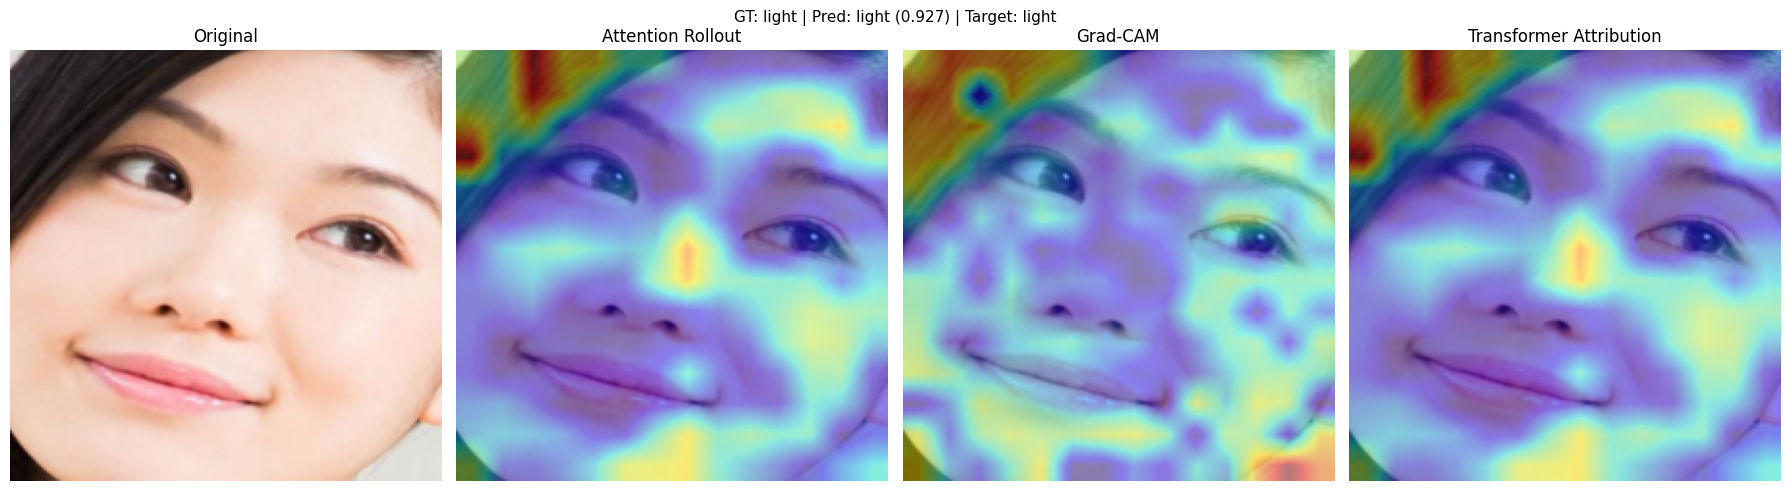

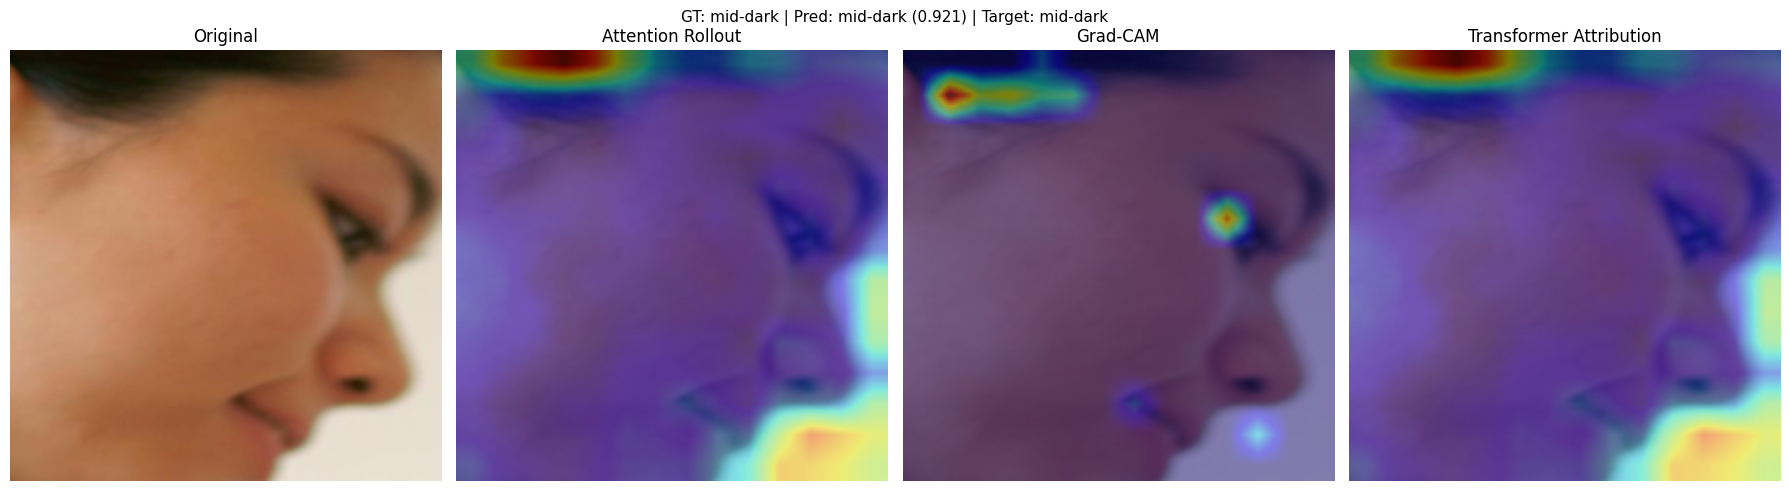

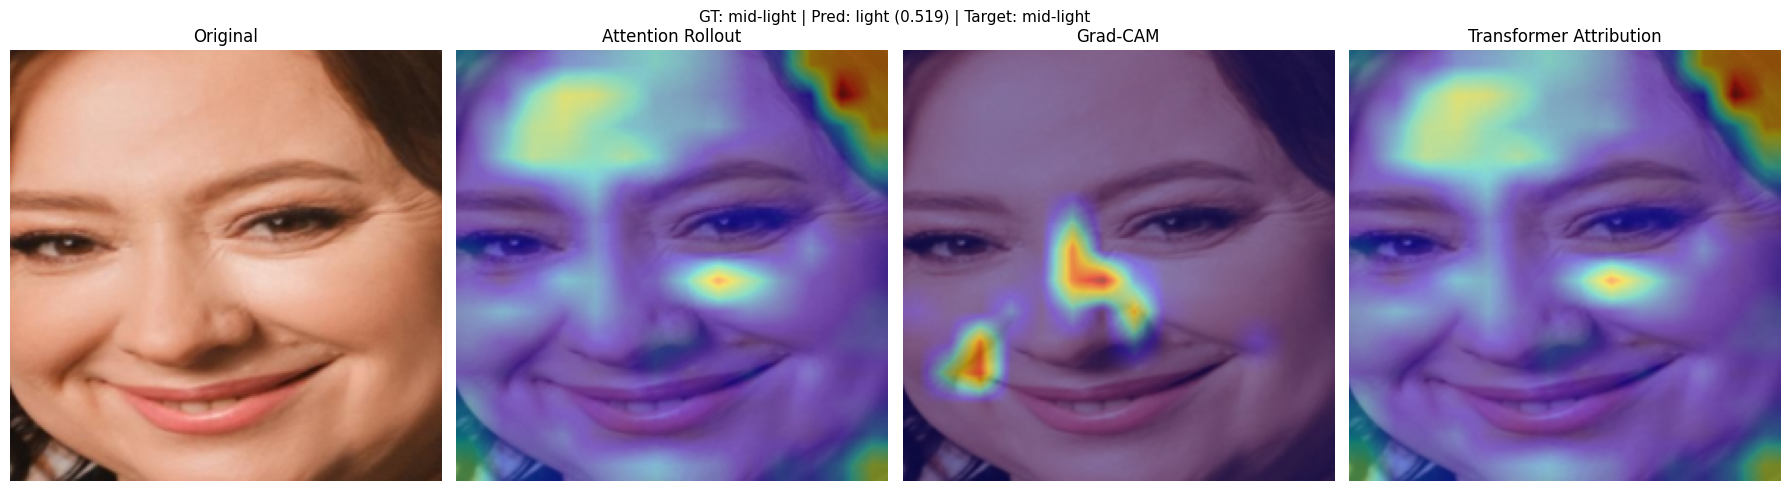

Done. ViT CAM generated for 4 image(s).
Output folder: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/cam_outputs_vit_simple
Summary CSV: /media/aejaz/New Volume/Projects/DERMAVISION/VIT/Skin-Tone-2/cam_outputs_vit_simple/cam_summary.csv


In [2]:
# ViT CAM (Attention Rollout + Grad-CAM + Transformer Attribution CAM)
# Supports:
# 1) Folder labels: test/<class_name>/*
# 2) CSV labels: test/_classes.csv (multi-label rows supported)

from pathlib import Path
import csv
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.transforms.functional import resize, center_crop
from torchvision.models import vit_b_16

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except Exception:
    %pip install -q grad-cam opencv-python
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ---------------------------
# Config
# ---------------------------
cwd = Path.cwd()
DATASET_REL_PATH = Path("dataset") / "Skin-Tone-2"
MANUAL_DATASET_ROOT = None

USE_CSV_LABELS_IF_AVAILABLE = True
CSV_LABEL_FILE = "_classes.csv"
CSV_FILENAME_COL = "filename"

MANUAL_CLASS_NAMES = None

MANUAL_MODEL_PATH = None
MODEL_CANDIDATES = [
    cwd / "best_vit_skin_tone.pth",
    cwd / "vit_skin_tone_last.pth",
    cwd / "best_vit_skin_tone_best_epoch_1.pth",
]
MODEL_GLOB_PATTERNS = [
    "best_vit_skin_tone_best_epoch_*.pth",
    "best_vit_skin_tone*.pth",
    "vit_skin_tone_last*.pth",
]

USE_MODEL_FROM_MEMORY_IF_AVAILABLE = True
ALLOW_PARTIAL_LOAD_IF_HEAD_MISMATCH = True

MAX_IMAGES_PER_CLASS = 1
USE_PREDICTED_CLASS_TARGET = False
CAM_OUTPUT_DIR = cwd / "cam_outputs_vit_simple"

# ---------------------------
# Paths
# ---------------------------
project_root = cwd
while project_root != project_root.parent and not (project_root / DATASET_REL_PATH).exists():
    project_root = project_root.parent

DATASET_ROOT = Path(MANUAL_DATASET_ROOT) if MANUAL_DATASET_ROOT else (project_root / DATASET_REL_PATH)
TEST_DIR = DATASET_ROOT / "test"

print("Working directory:", cwd)
print("Project root:", project_root)
print("Dataset root:", DATASET_ROOT)
print("Test dir:", TEST_DIR)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {DATASET_ROOT}\\n"
        "Set MANUAL_DATASET_ROOT at the top of this cell if needed."
    )
if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"Test directory not found: {TEST_DIR}\\n"
        "Expected test folder under DATASET_ROOT."
    )

# ---------------------------
# Label parsing (folder or CSV)
# ---------------------------
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
classes_csv_path = TEST_DIR / CSV_LABEL_FILE
images_by_class = {}

if USE_CSV_LABELS_IF_AVAILABLE and classes_csv_path.exists():
    print("Using CSV label format:", classes_csv_path)
    all_test_images = sorted([
        p for p in TEST_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])
    name_to_paths = {}
    for p in all_test_images:
        name_to_paths.setdefault(p.name, []).append(p)

    with classes_csv_path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        header = reader.fieldnames or []
        class_names = [h for h in header if h and h != CSV_FILENAME_COL]

        if len(class_names) == 0:
            raise RuntimeError(
                f"No class columns found in {classes_csv_path}. "
                f"Expected a filename column '{CSV_FILENAME_COL}' and class columns."
            )

        images_by_class = {c: [] for c in class_names}
        for row in reader:
            filename = str(row.get(CSV_FILENAME_COL, "")).strip()
            if not filename:
                continue

            img_path = TEST_DIR / filename
            if not img_path.exists():
                matches = name_to_paths.get(Path(filename).name, [])
                if len(matches) > 0:
                    img_path = matches[0]
                else:
                    continue

            positive_classes = []
            for cname in class_names:
                raw = str(row.get(cname, "")).strip()
                try:
                    is_positive = float(raw) > 0
                except Exception:
                    is_positive = raw.lower() in {"1", "true", "yes", "y"}
                if is_positive:
                    positive_classes.append(cname)

            for cname in positive_classes:
                images_by_class[cname].append(img_path)
else:
    print("Using folder label format: test/<class_name>/*")
    class_dirs = sorted([d for d in TEST_DIR.iterdir() if d.is_dir()])
    class_names = [d.name for d in class_dirs]
    images_by_class = {}
    for class_dir in class_dirs:
        image_paths = sorted([
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ])
        images_by_class[class_dir.name] = image_paths

if MANUAL_CLASS_NAMES is not None:
    class_names = list(MANUAL_CLASS_NAMES)
    for cname in class_names:
        images_by_class.setdefault(cname, [])

for cname in class_names:
    seen = set()
    unique_paths = []
    for p in images_by_class.get(cname, []):
        key = str(p)
        if key not in seen:
            seen.add(key)
            unique_paths.append(p)
    images_by_class[cname] = unique_paths

num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

if num_classes == 0:
    raise RuntimeError(f"No classes found in test data: {TEST_DIR}")

# ---------------------------
# Model + transforms
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

if MANUAL_MODEL_PATH:
    model_path = Path(MANUAL_MODEL_PATH)
else:
    model_path = next((p for p in MODEL_CANDIDATES if p.exists()), None)
    if model_path is None:
        search_dirs = [
            cwd,
            project_root / "VIT" / "Skin-Tone-2",
            project_root / "VIT",
        ]
        for d in search_dirs:
            if not d.exists():
                continue
            for pattern in MODEL_GLOB_PATTERNS:
                matches = sorted(d.glob(pattern))
                if len(matches) > 0:
                    model_path = matches[-1]
                    break
            if model_path is not None:
                break

if USE_MODEL_FROM_MEMORY_IF_AVAILABLE and "model" in globals():
    print("Using model already in memory.")
    model = model.to(device)
else:
    if model_path is None:
        raise FileNotFoundError(
            "No ViT checkpoint found automatically. Set MANUAL_MODEL_PATH at the top of this cell."
        )

    state_dict = torch.load(model_path, map_location=device)
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    if isinstance(state_dict, dict):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    model = vit_b_16(weights=None)
    in_features = model.heads.head.in_features
    model.heads = nn.Sequential(
        nn.LayerNorm(in_features),
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )

    if ALLOW_PARTIAL_LOAD_IF_HEAD_MISMATCH and isinstance(state_dict, dict):
        model_state = model.state_dict()
        filtered_state = {}
        skipped_keys = []
        for k, v in state_dict.items():
            if k in model_state and model_state[k].shape == v.shape:
                filtered_state[k] = v
            else:
                skipped_keys.append(k)

        if len(skipped_keys) > 0:
            print(f"Skipped {len(skipped_keys)} incompatible key(s) during load.")

        model.load_state_dict(filtered_state, strict=False)
    else:
        model.load_state_dict(state_dict, strict=False)

model = model.to(device)
model.eval()
for param in model.parameters():
    param.requires_grad = True

# ---------------------------
# CAM helpers
# ---------------------------
def _extract_logits(output):
    if hasattr(output, "logits"):
        return output.logits
    if isinstance(output, tuple):
        return output[0]
    return output


def _to_2d_cam(cam, out_hw=(224, 224)):
    cam_t = torch.tensor(cam, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    cam_t = F.interpolate(cam_t, size=out_hw, mode="bilinear", align_corners=False)
    cam_2d = cam_t.squeeze().cpu().numpy()
    cam_2d = cam_2d - cam_2d.min()
    cam_2d = cam_2d / (cam_2d.max() + 1e-8)
    return cam_2d


def _overlay_cam(rgb_img, cam_2d, alpha=0.45):
    heatmap = plt.get_cmap("jet")(cam_2d)[..., :3]
    overlay = (1 - alpha) * rgb_img + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)
    return overlay


def _vit_reshape_transform(tensor):
    # tensor: [B, tokens, C] where token 0 is class token.
    tensor = tensor[:, 1:, :]
    n_tokens = tensor.size(1)
    h = int(math.sqrt(n_tokens))
    w = h
    tensor = tensor.reshape(tensor.size(0), h, w, tensor.size(2))
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor


def _collect_attention_weights(vit_model, input_tensor, keep_grad=False):
    attn_weights = []
    hooks = []
    originals = []

    for block in vit_model.encoder.layers:
        sa = block.self_attention
        orig_forward = sa.forward
        originals.append((sa, orig_forward))

        def wrapped_forward(*args, _orig=orig_forward, **kwargs):
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = False
            return _orig(*args, **kwargs)

        sa.forward = wrapped_forward

        def hook_fn(module, inp, out):
            weights = out[1]
            if weights is not None:
                if keep_grad:
                    weights.retain_grad()
                attn_weights.append(weights)

        hooks.append(sa.register_forward_hook(hook_fn))

    try:
        output = vit_model(input_tensor)
        logits = _extract_logits(output)
    finally:
        for h in hooks:
            h.remove()
        for sa, orig_forward in originals:
            sa.forward = orig_forward

    return logits, attn_weights


def _attention_rollout_map(vit_model, input_tensor):
    with torch.no_grad():
        _, attn_list = _collect_attention_weights(vit_model, input_tensor, keep_grad=False)

    if len(attn_list) == 0:
        raise RuntimeError("No attention weights captured for rollout.")

    joint = None
    for attn in attn_list:
        # attn shape: [B, heads, tokens, tokens]
        a = attn.mean(dim=1)
        eye = torch.eye(a.size(-1), device=a.device).unsqueeze(0)
        a = a + eye
        a = a / a.sum(dim=-1, keepdim=True).clamp(min=1e-6)
        joint = a if joint is None else torch.bmm(a, joint)

    cls_to_patches = joint[0, 0, 1:]
    side = int(math.sqrt(cls_to_patches.numel()))
    cam = cls_to_patches.reshape(side, side).detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam


def _transformer_attribution_cam(vit_model, input_tensor, target_idx):
    logits, attn_list = _collect_attention_weights(vit_model, input_tensor, keep_grad=True)

    if len(attn_list) == 0:
        raise RuntimeError("No attention weights captured for transformer attribution.")

    vit_model.zero_grad(set_to_none=True)
    target_score = logits[:, target_idx].sum()
    target_score.backward()

    joint = None
    used_gradients = False
    for attn in attn_list:
        grad = attn.grad

        # Some torchvision / PyTorch attention paths do not expose gradients
        # for returned attention weights. Fallback keeps attribution usable.
        if grad is None:
            a = attn.mean(dim=1)
        else:
            a = (attn * grad).clamp(min=0).mean(dim=1)
            used_gradients = True

        eye = torch.eye(a.size(-1), device=a.device).unsqueeze(0)
        a = a + eye
        a = a / a.sum(dim=-1, keepdim=True).clamp(min=1e-6)
        joint = a if joint is None else torch.bmm(a, joint)

    if joint is None:
        raise RuntimeError("Transformer attribution failed: no usable attention maps.")

    if not used_gradients:
        print("Warning: attention gradients unavailable; using attention-only attribution fallback.")

    cls_to_patches = joint[0, 0, 1:]
    side = int(math.sqrt(cls_to_patches.numel()))
    cam = cls_to_patches.reshape(side, side).detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam


# ---------------------------
# Build Grad-CAM object for ViT
# ---------------------------
TARGET_LAYER = model.encoder.layers[-1].ln_1
grad_cam = GradCAM(
    model=model,
    target_layers=[TARGET_LAYER],
    reshape_transform=_vit_reshape_transform,
)

# ---------------------------
# Run CAMs
# ---------------------------
CAM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
records = []

for class_name in class_names:
    true_idx = class_to_idx[class_name]
    image_paths = images_by_class.get(class_name, [])
    if MAX_IMAGES_PER_CLASS is not None:
        image_paths = image_paths[:MAX_IMAGES_PER_CLASS]
    if len(image_paths) == 0:
        continue

    out_class_dir = CAM_OUTPUT_DIR / class_name
    out_class_dir.mkdir(parents=True, exist_ok=True)

    for img_path in image_paths:
        pil_img = Image.open(img_path).convert("RGB")
        vis_pil = center_crop(resize(pil_img, [256, 256]), [224, 224])
        rgb_img = np.array(vis_pil).astype(np.float32) / 255.0

        input_tensor = eval_transform(pil_img).unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        with torch.no_grad():
            logits = _extract_logits(model(input_tensor))
            probs = torch.softmax(logits, dim=1)[0]
            pred_idx = int(torch.argmax(probs).item())
            pred_conf = float(probs[pred_idx].item())

        target_idx = pred_idx if USE_PREDICTED_CLASS_TARGET else true_idx
        if target_idx >= logits.shape[1]:
            continue

        targets = [ClassifierOutputTarget(target_idx)]

        model.zero_grad(set_to_none=True)
        cam_grad = grad_cam(input_tensor=input_tensor, targets=targets)[0]
        cam_roll = _attention_rollout_map(model, input_tensor)
        cam_attr = _transformer_attribution_cam(model, input_tensor, target_idx)

        cam_grad = _to_2d_cam(cam_grad, out_hw=(224, 224))
        cam_roll = _to_2d_cam(cam_roll, out_hw=(224, 224))
        cam_attr = _to_2d_cam(cam_attr, out_hw=(224, 224))

        overlay_grad = _overlay_cam(rgb_img, cam_grad)
        overlay_roll = _overlay_cam(rgb_img, cam_roll)
        overlay_attr = _overlay_cam(rgb_img, cam_attr)

        pred_name = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)
        target_name = class_names[target_idx] if target_idx < len(class_names) else str(target_idx)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        axes[0].imshow(rgb_img)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(overlay_roll)
        axes[1].set_title("Attention Rollout")
        axes[1].axis("off")

        axes[2].imshow(overlay_grad)
        axes[2].set_title("Grad-CAM")
        axes[2].axis("off")

        axes[3].imshow(overlay_attr)
        axes[3].set_title("Transformer Attribution")
        axes[3].axis("off")

        fig.suptitle(
            f"GT: {class_name} | Pred: {pred_name} ({pred_conf:.3f}) | Target: {target_name}",
            fontsize=11,
        )
        plt.tight_layout()

        out_file = out_class_dir / f"{img_path.stem}_vit_cam_grid.png"
        fig.savefig(out_file, dpi=180, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        records.append({
            "class_name": class_name,
            "image_path": str(img_path),
            "prediction": pred_name,
            "prediction_confidence": pred_conf,
            "target": target_name,
            "output_file": str(out_file),
        })

print(f"Done. ViT CAM generated for {len(records)} image(s).")
print("Output folder:", CAM_OUTPUT_DIR)

try:
    import pandas as pd
    summary_csv = CAM_OUTPUT_DIR / "cam_summary.csv"
    pd.DataFrame(records).to_csv(summary_csv, index=False)
    print("Summary CSV:", summary_csv)
except Exception:
    print("Pandas not available; skipping CSV summary.")